# 🤖 AI - Powered Candidate Hiring Decision Prediction 

## Machine Learning Project for Recruitement Analytics


### Developed By:
Akhila K
---


### Project Overview
Recruitment is a crucial business process that involves identifying and selecting the most suitable candidates for a job role. Organizations receive a large number of applications, making manual screening time-consuming and inefficient.

This project leverages Machine Learning algorithms to predict whether a candidate is likely to be hired based on factors such as education, experience, interview performance, skills, personality assessment, and recruitment strategy.

The system aims to support HR professionals by automating the candidate screening process and improving recruitment efficiency through data-driven decision-making.

# 🎯 Problem Statement

Hiring the right candidate is one of the most important decisions for an organization.

Traditional recruitment processes often involve manual evaluation of candidate profiles, which can be time-consuming and susceptible to bias.

The objective of this project is to develop a Machine Learning model capable of predicting hiring decisions using candidate information such as:

- Age
- Gender
- Education Level
- Experience
- Previous Companies Worked
- Interview Performance
- Skill Assessment
- Personality Assessment
- Recruitment Strategy

Target Variable:

✅ 1 = Hired

❌ 0 = Not Hired

The model will assist recruiters in making faster and more accurate hiring decisions.

<img src="Candidate.png" width="1000">

# 🛠 Tools & Technologies Used
### Programming Language
- Python

### Data Manipulation
- Pandas
- NumPy

### Data Visualization
- Matplotlib
- Seaborn

### Machine Learning Algorithms
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Gradient Boosting Classifier

### Model Evaluation
- Accuracy Score
- Confusion Matrix
- Classification Report

### Deployment
- Streamlit

### Development Environment
- Jupyter Notebook
- VS Code

# 📊 Project Workflow

1. Import Libraries
2. Load Dataset
3. Data Understanding
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Feature Selection
7. Data Scaling
8. Model Building
9. Model Comparison
10. Model Evaluation
11. Feature Importance Analysis
12. Hiring Prediction
13. Streamlit Deployment

In [6]:
# import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import(
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# 📂 Load Dataset

In [8]:
df = pd.read_csv(r"recruitment_data.csv")
df.head()

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26,1,2,0,3,26.783828,48,78,91,1,1
1,39,1,4,12,3,25.862694,35,68,80,2,1
2,48,0,2,3,2,9.920805,20,67,13,2,0
3,34,1,2,5,2,6.407751,36,27,70,3,0
4,30,0,1,6,1,43.105343,23,52,85,2,0


# 🔍 Dataset Information

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1500 non-null   int64  
 1   Gender               1500 non-null   int64  
 2   EducationLevel       1500 non-null   int64  
 3   ExperienceYears      1500 non-null   int64  
 4   PreviousCompanies    1500 non-null   int64  
 5   DistanceFromCompany  1500 non-null   float64
 6   InterviewScore       1500 non-null   int64  
 7   SkillScore           1500 non-null   int64  
 8   PersonalityScore     1500 non-null   int64  
 9   RecruitmentStrategy  1500 non-null   int64  
 10  HiringDecision       1500 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 129.0 KB


In [11]:
df.describe()

,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,35.148667,0.492000,2.188000,7.694000,3.00200,25.505379,50.564000,51.116000,49.387333,1.893333,0.310000
std,9.252728,0.500103,0.862449,4.641414,1.41067,14.567151,28.626215,29.353563,29.353201,0.689642,0.462647
min,20.000000,0.000000,1.000000,0.000000,1.00000,1.031376,0.000000,0.000000,0.000000,1.000000,0.000000
25%,27.000000,0.000000,2.000000,4.000000,2.00000,12.838851,25.000000,25.750000,23.000000,1.000000,0.000000
50%,35.000000,0.000000,2.000000,8.000000,3.00000,25.502239,52.000000,53.000000,49.000000,2.000000,0.000000
75%,43.000000,1.000000,3.000000,12.000000,4.00000,37.737996,75.000000,76.000000,76.000000,2.000000,1.000000
max,50.000000,1.000000,4.000000,15.000000,5.00000,50.992462,100.000000,100.000000,100.000000,3.000000,1.000000


In [12]:
df.shape

(1500, 11)

# ❓ Missing Value Analysis

In [14]:
df.isnull().sum()

Age                    0
Gender                 0
EducationLevel         0
ExperienceYears        0
PreviousCompanies      0
DistanceFromCompany    0
InterviewScore         0
SkillScore             0
PersonalityScore       0
RecruitmentStrategy    0
HiringDecision         0
dtype: int64

# 📈 Correlation Heatmap

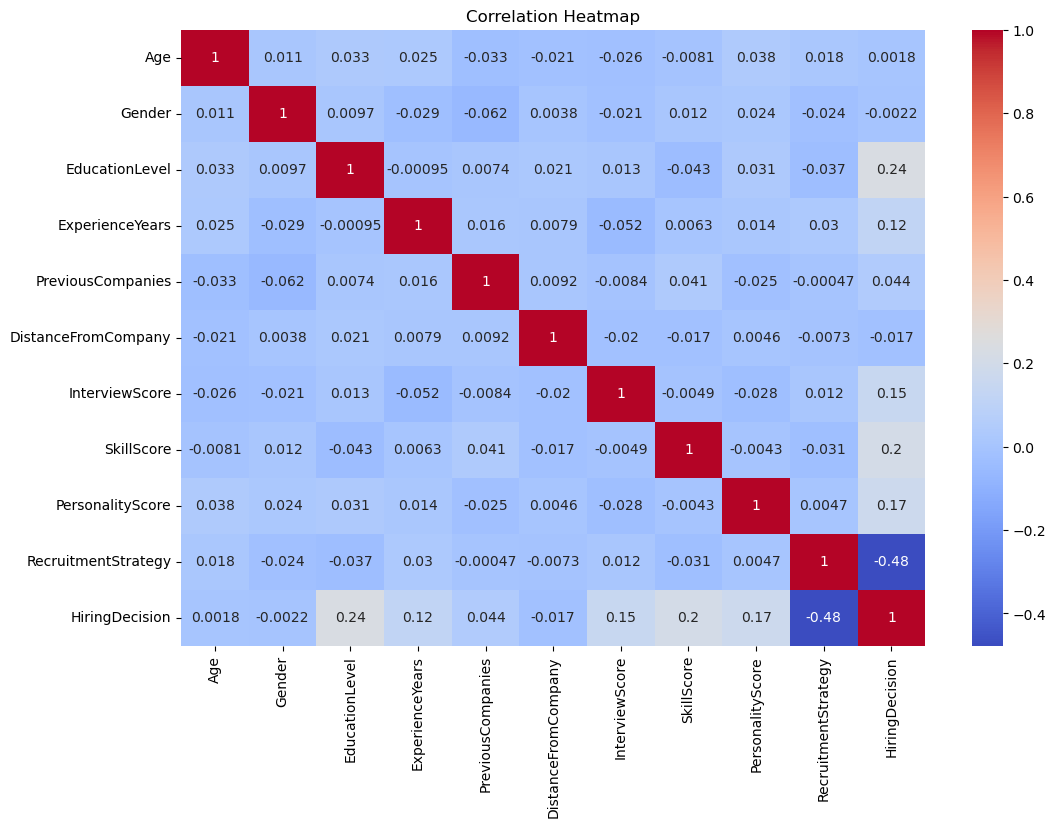

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

# 🎯 Feature Selection

In [18]:
X = df.drop("HiringDecision", axis=1)

y = df["HiringDecision"]

print(X.shape)
print(y.shape)

(1500, 10)
(1500,)


# ✂️ Train Test Split

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20)

# ⚖️ Feature Scaling

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🤖 Model Training & Evaluation

In [24]:
models = {
    "Logistic Regression" : LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN" : KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(),
    "Gradient Boosting" : GradientBoostingClassifier()
}

results = []
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    pred=model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test,pred)
    results.append([name,accuracy])
    
    print(f"\n{name}")
    print("-"*40)
    print("Accuracy:", accuracy)
    


Logistic Regression
----------------------------------------
Accuracy: 0.8866666666666667

Decision Tree
----------------------------------------
Accuracy: 0.9066666666666666

Random Forest
----------------------------------------
Accuracy: 0.9433333333333334

KNN
----------------------------------------
Accuracy: 0.8766666666666667

SVM
----------------------------------------
Accuracy: 0.8866666666666667

Gradient Boosting
----------------------------------------
Accuracy: 0.9433333333333334


# 🏆 Model Comparison

In [26]:
results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy"]
)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
2,Random Forest,0.943333
5,Gradient Boosting,0.943333
1,Decision Tree,0.906667
0,Logistic Regression,0.886667
4,SVM,0.886667
3,KNN,0.876667


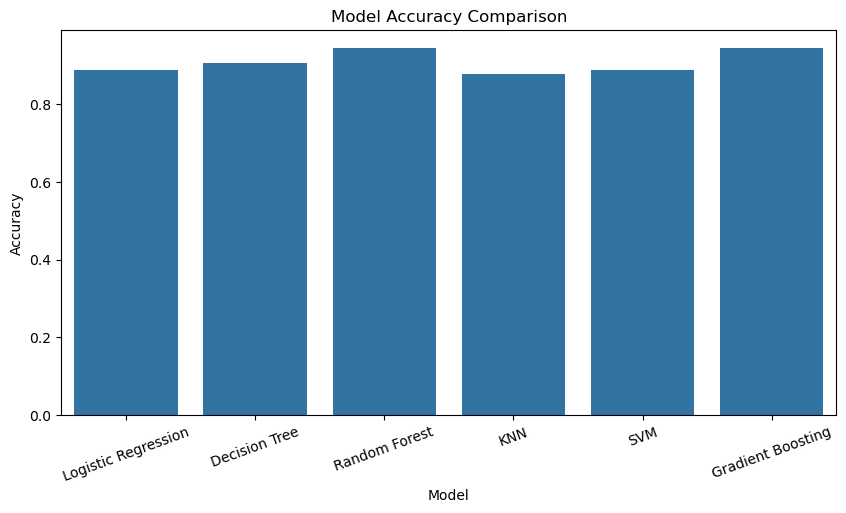

In [27]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=20)

plt.title("Model Accuracy Comparison")

plt.show()

# HYPERPARAMETER TUNING FOR ALL MODELS

In [29]:
param_grids = {

    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear", "lbfgs"]
    },

    "Decision Tree": {
        "criterion": ["gini", "entropy"],
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10]
    },

    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },

    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"]
    },

    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },

    "Gradient Boosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5]
    }
}

# MODEL TUNING & EVALUATION

In [31]:
optimized_results = []

best_models = {}

for name, model in models.items():

    print(f"\n{'='*60}")
    print(f"Tuning {name}")
    print(f"{'='*60}")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid_search.fit(X_train_scaled, y_train)

    best_model = grid_search.best_estimator_

    best_models[name] = best_model

    y_pred = best_model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    optimized_results.append([
        name,
        accuracy,
        grid_search.best_params_
    ])

    print("Best Parameters:")
    print(grid_search.best_params_)

    print("\nAccuracy:", round(accuracy,4))


Tuning Logistic Regression
Best Parameters:
{'C': 0.01, 'solver': 'liblinear'}

Accuracy: 0.8833

Tuning Decision Tree
Best Parameters:
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10}

Accuracy: 0.92

Tuning Random Forest
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Accuracy: 0.9467

Tuning KNN
Best Parameters:
{'n_neighbors': 9, 'weights': 'distance'}

Accuracy: 0.8733

Tuning SVM
Best Parameters:
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

Accuracy: 0.8867

Tuning Gradient Boosting
Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

Accuracy: 0.9433


# OPTIMIZED MODEL COMPARISON


In [33]:
optimized_df = pd.DataFrame(
    optimized_results,
    columns=["Model", "Accuracy", "Best Parameters"]
)

optimized_df = optimized_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*80)
print("OPTIMIZED MODEL COMPARISON")
print("="*80)

display(optimized_df)



OPTIMIZED MODEL COMPARISON


,Model,Accuracy,Best Parameters
2,Random Forest,0.946667,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
5,Gradient Boosting,0.943333,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
1,Decision Tree,0.920000,"{'criterion': 'entropy', 'max_depth': 10, 'min..."
4,SVM,0.886667,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}"
0,Logistic Regression,0.883333,"{'C': 0.01, 'solver': 'liblinear'}"
3,KNN,0.873333,"{'n_neighbors': 9, 'weights': 'distance'}"


# VISUALIZATION

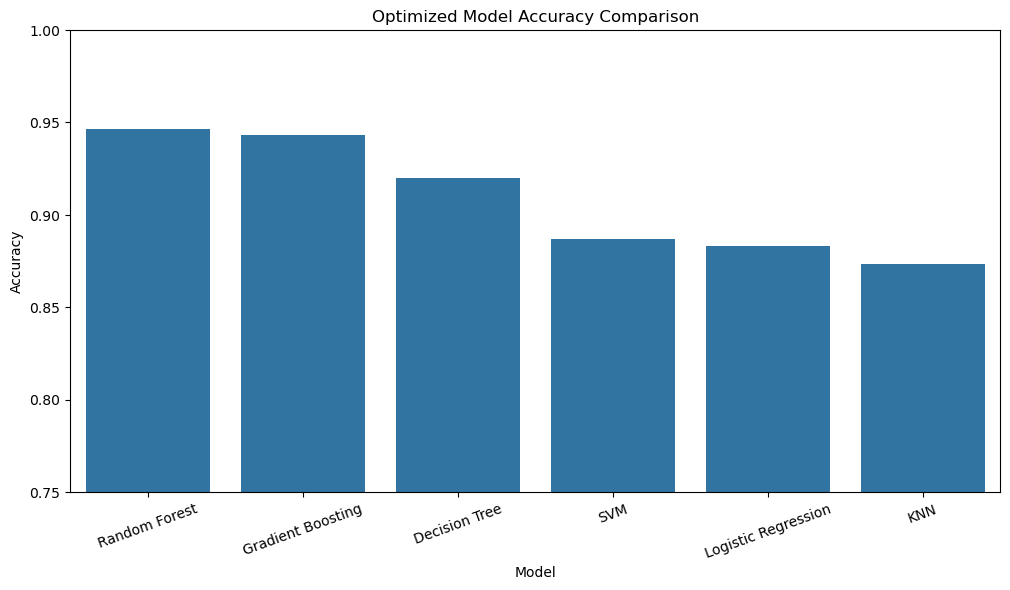

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=optimized_df,
    x="Model",
    y="Accuracy"
)

plt.title("Optimized Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.ylim(0.75,1)

plt.show()


# BEST MODEL SELECTION

In [37]:
best_model_name = optimized_df.iloc[0]["Model"]

best_model = best_models[best_model_name]

print("\n")
print("="*80)
print("BEST OPTIMIZED MODEL")
print("="*80)

print("Best Model :", best_model_name)




BEST OPTIMIZED MODEL
Best Model : Random Forest


# FINAL EVALUATION OF BEST MODEL

In [39]:
y_pred = best_model.predict(X_test_scaled)

final_accuracy = accuracy_score(y_test, y_pred)

print("\nFinal Accuracy:", round(final_accuracy,4))

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))


Final Accuracy: 0.9467

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       213
           1       0.93      0.89      0.91        87

    accuracy                           0.95       300
   macro avg       0.94      0.93      0.93       300
weighted avg       0.95      0.95      0.95       300



# CONFUSION MATRIX

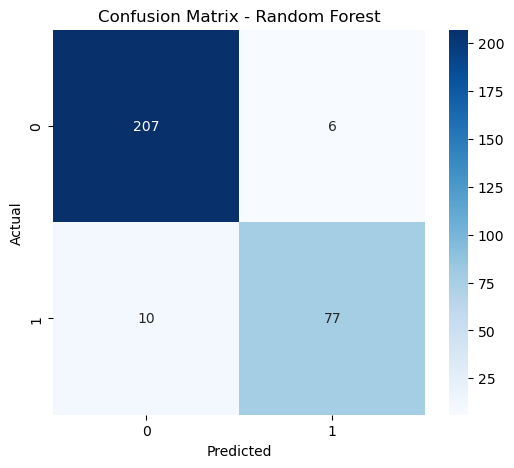

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# FEATURE IMPORTANCE


Feature Importance


,Feature,Importance
9,RecruitmentStrategy,0.298470
7,SkillScore,0.128866
8,PersonalityScore,0.116171
6,InterviewScore,0.112262
3,ExperienceYears,0.088999
2,EducationLevel,0.088764
5,DistanceFromCompany,0.071987
0,Age,0.054116
4,PreviousCompanies,0.028731
1,Gender,0.011634


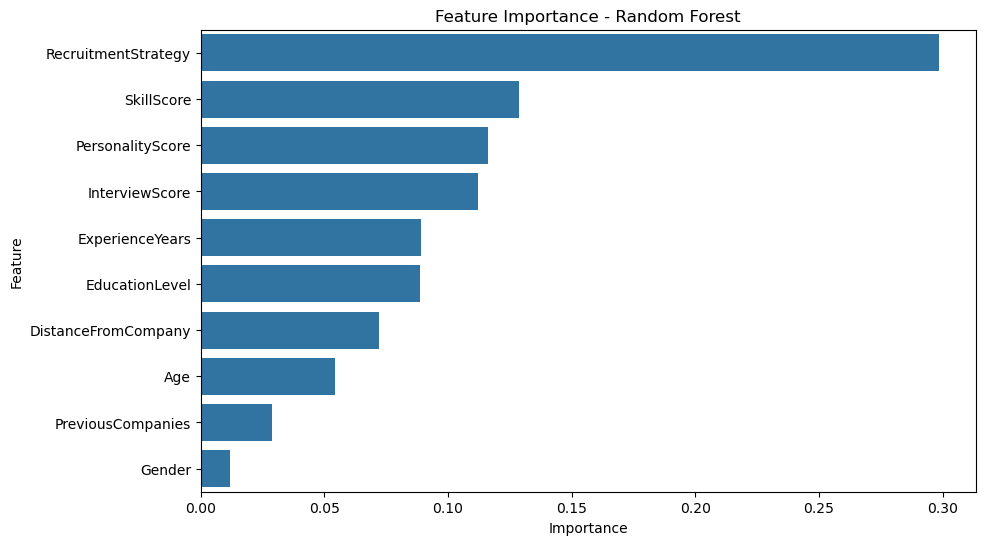

In [43]:
if hasattr(best_model, "feature_importances_"):

    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\nFeature Importance")

    display(feature_importance)

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=feature_importance,
        x="Importance",
        y="Feature"
    )

    plt.title(f"Feature Importance - {best_model_name}")

    plt.show()

# SAVE BEST MODEL USING PICKLE

In [79]:
import joblib

best_model.fit(X_train_scaled, y_train)

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# SAVE SCALER USING PICKLE

In [47]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler Saved Successfully -> scaler.pkl")

Scaler Saved Successfully -> scaler.pkl


# LOAD MODEL EXAMPLE

In [49]:
with open("best_model.pkl", "rb") as file:
     loaded_model = pickle.load(file)
with open("scaler.pkl", "rb") as file:
     loaded_scaler = pickle.load(file)
print("\nMachine Learning Pipeline Completed Successfully!")


Machine Learning Pipeline Completed Successfully!


In [50]:
#pip install scikit-learn==1.3.2

  Using cached scikit_learn-1.3.2-cp312-cp312-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.3.2-cp312-cp312-win_amd64.whl (9.1 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.4.2
    Uninstalling scikit-learn-1.4.2:
      Successfully uninstalled scikit-learn-1.4.2
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
feature-engine 1.8.3 requires scikit-learn>=1.4.0, but you have scikit-learn 1.3.2 which is incompatible.


In [51]:
#pip install --upgrade scikit-learn==1.4.2

  Using cached scikit_learn-1.4.2-cp312-cp312-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.4.2-cp312-cp312-win_amd64.whl (10.6 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.3.2
    Uninstalling scikit-learn-1.3.2:
      Successfully uninstalled scikit-learn-1.3.2
Note: you may need to restart the kernel to use updated packages.
